## Phase 0 - EDA Mini-Project

This notebook contains an analysis of 1000 anonymous high school students' test scores in math, reading and writing. It also contains information about the students, namely, their gender, education level of their parents, lunch level, and whether they completed a test preparation course. We will conduct some univariate analysis and bivariate analysis, as well as calculating aggregate statistics in different groups/categories.

<hr>

Loading in the neccessary libraries

In [3]:

import pandas as pd
import matplotlib.pyplot as plt

Import our dataset into the notebook

In [4]:
df = pd.read_csv('exams.csv')

Let us take a bird's eye overview at the dataset.

In [5]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,male,group A,high school,standard,completed,67,67,63
1,female,group D,some high school,free/reduced,none,40,59,55
2,male,group E,some college,free/reduced,none,59,60,50
3,male,group B,high school,standard,none,77,78,68
4,male,group E,associate's degree,standard,completed,78,73,68


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


<hr>

#### On Missing Values:
This dataset contains no null or NaN values in its columns. This dataset may have been cleaned before being posted on Kaggle.

In [7]:
df.isna().sum().sum()

np.int64(0)

<hr>

#### Univariate Analysis
Let us look at some of the key variables.

##### Analysis of Math Scores

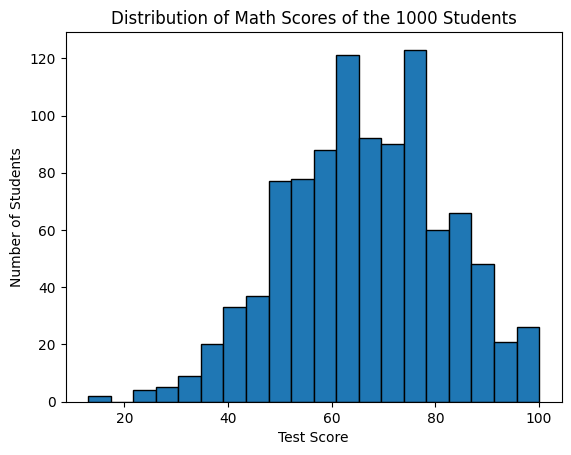

In [8]:
plt.hist(df['math score'], edgecolor="black", bins=20)
plt.title("Distribution of Math Scores of the 1000 Students")
plt.xlabel("Test Score")
plt.ylabel("Number of Students")
plt.show()

In [9]:
print(f'Skewness: {df["math score"].skew()}')
print(f'Standard Deviation: {df['math score'].std()}')
print(f'Mean: {df['math score'].mean()}')

Skewness: -0.15114748214330356
Standard Deviation: 15.402870915268766
Mean: 66.396


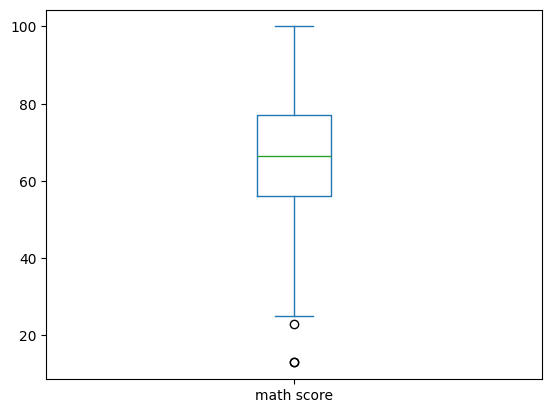

In [10]:
df['math score'].plot.box()
plt.show()

The distribution of the math scores of the 1000 students is approximately symmetric (skew of -0.15). The average score is 66.396 out of 100.
With an SD of +-15.40, the scores are clustered around 50-80, though not tightly visually.  Three low outliers reside.


In [11]:
low_fence = (df['math score'].quantile(0.25)) - (1.5 * (df['math score'].quantile(0.75) - df['math score'].quantile(0.25)))
df.loc[df["math score"] < low_fence]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
18,female,group C,associate's degree,free/reduced,none,23,44,44
392,female,group C,some college,free/reduced,none,13,29,23
832,female,group D,some college,free/reduced,none,13,36,37


The snippet above shows the three outliers found in the box plot. There are the two female students (id of 392 and 832) who got the lowest score of 13, and a female student who got a 23 in math, marked as a low outlier.

<hr>

##### Analysis of Reading Scores

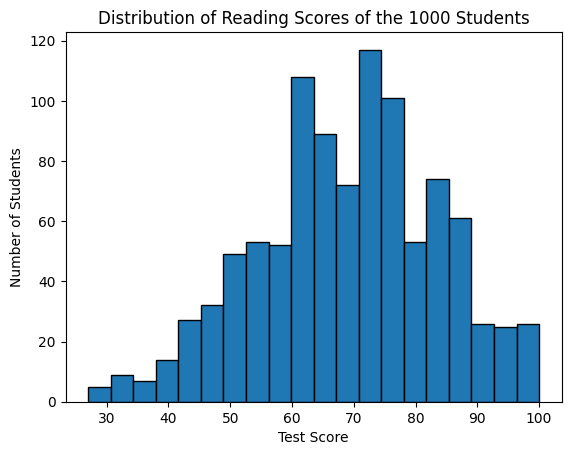

In [12]:
plt.hist(df['reading score'], edgecolor="black", bins=20)
plt.title("Distribution of Reading Scores of the 1000 Students")
plt.xlabel("Test Score")
plt.ylabel("Number of Students")
plt.show()

In [13]:
print(f'Skewness: {df['reading score'].skew()}')
print(f'Standard Deviation: {df['reading score'].std()}')
print(f"Mean: {df['reading score'].mean()}")

Skewness: -0.1916649731940658
Standard Deviation: 14.737271904364905
Mean: 69.002


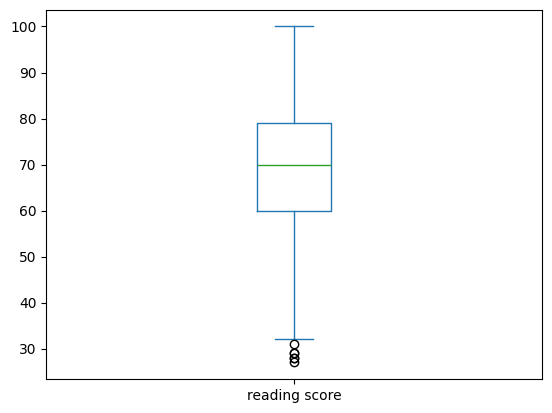

In [14]:
df['reading score'].plot.box()  
plt.show()

In [15]:
iqr = df['reading score'].quantile(0.75) - df['reading score'].quantile(0.25)
low_fence = df['reading score'].quantile(0.25) - (1.5 * iqr)
df.loc[df['reading score'] < low_fence]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
300,male,group B,some college,free/reduced,none,43,28,24
392,female,group C,some college,free/reduced,none,13,29,23
689,male,group C,some college,free/reduced,none,36,27,26
885,male,group B,high school,free/reduced,none,37,28,23
899,male,group C,some high school,free/reduced,none,45,31,27
976,female,group B,some college,free/reduced,completed,31,29,35


The distribution of the reading scores of 1000 students is approximately symmetric (skew of -0.19), with most number of scores visually clustering around 60-70. This sampel's mean score is slightly higher than the math score, at 69.002, with standard deviation of +=14.74. There are six outliers in this distribution, listed in this table above. 

<hr>

##### Analysis of Writing Scores

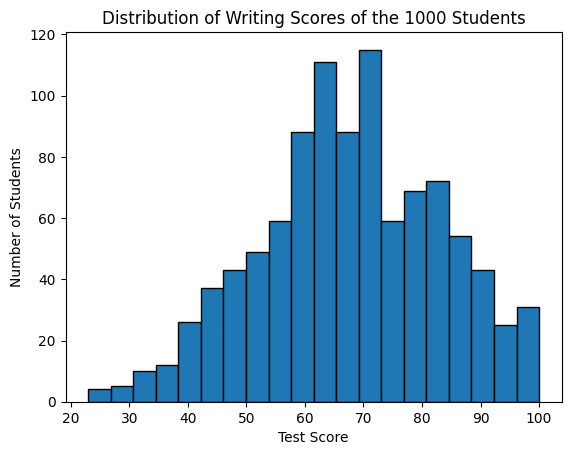

In [16]:
plt.hist(df["writing score"], edgecolor="black", bins=20)
plt.title("Distribution of Writing Scores of the 1000 Students")
plt.xlabel("Test Score")
plt.ylabel("Number of Students")
plt.show()

In [17]:
print(f"Skewness: {df['writing score'].skew()}")
print(f"Mean: {df['writing score'].mean()}")
print(f"Standard Deviation: {df['writing score'].std()}")

Skewness: -0.15362079764914593
Mean: 67.738
Standard Deviation: 15.600985441527298


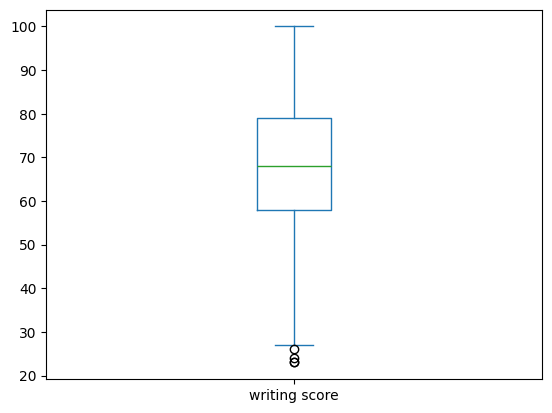

In [18]:
df['writing score'].plot.box()
plt.show()

The distribution of the writing scores of the 1000 students is also approximately symmetric (skew of -0.15), along with the other test score distributions, with the most number of scores  around 60-70. Although visually more clustered around the mean of 67.738, the distribution actually has a higher standard deviation of +=15.60. Four low outliers are contained in this distribution. 

In [19]:
iqr = df['writing score'].quantile(0.75) - df['writing score'].quantile(0.25)
low_fence = df['writing score'].quantile(0.25) - (1.5 * iqr)
df.loc[df['writing score'] < low_fence]

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
300,male,group B,some college,free/reduced,none,43,28,24
392,female,group C,some college,free/reduced,none,13,29,23
689,male,group C,some college,free/reduced,none,36,27,26
885,male,group B,high school,free/reduced,none,37,28,23


<hr>
##### Observations:
- All distributions are approximately symmetric, though all have small negative skew values. 
- All distributions contain some low outliers, without any high outliers.

<hr>

##### Analysis of Categorical Variables

Let us see the breakdown of the gender variable.

In [20]:
df['gender'].value_counts()

gender
male      517
female    483
Name: count, dtype: int64

Next, let us analyze the composition of the race/ethiniticty groups.

In [21]:
df["race/ethnicity"].value_counts()

race/ethnicity
group C    323
group D    262
group B    205
group E    131
group A     79
Name: count, dtype: int64

Viewed in a bar plot

<Axes: xlabel='race/ethnicity'>

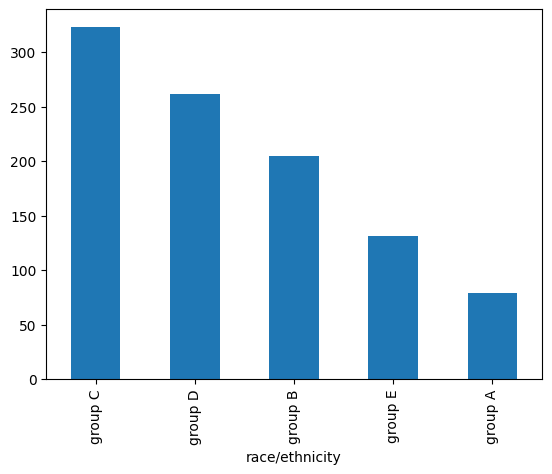

In [22]:
df["race/ethnicity"].value_counts().plot.bar()

What these groups signify is not in the scope of this report.

<hr>

Let us now analyze the breakdown of the parental education level for the 1000 students.

In [23]:
df['parental level of education'].value_counts()

parental level of education
some college          222
associate's degree    203
high school           202
some high school      191
bachelor's degree     112
master's degree        70
Name: count, dtype: int64

It would also be better to visualize this variable using a bar plot.

<Axes: xlabel='parental level of education'>

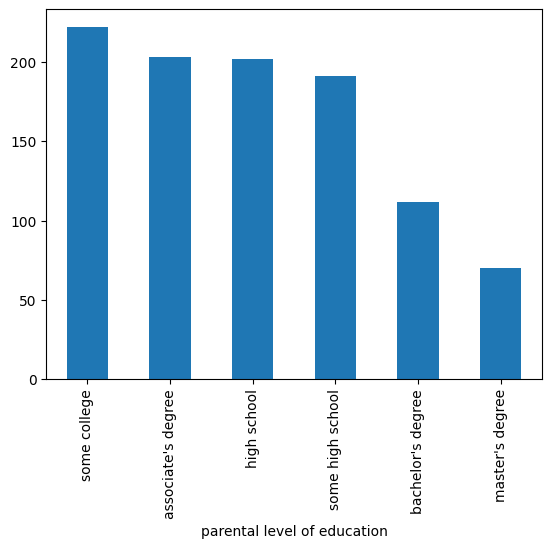

In [24]:
df['parental level of education'].value_counts().plot.bar()

<hr>

#### Bivariate Analysis
In this section, we will look at potential associations between groups and variables.

##### Aggregation - Grouping by Race/Ethnicity

Let us see the parental level of education based on race/ethnicity

In [25]:
df.groupby("race/ethnicity").agg(
    level_of_education = ("parental level of education", "value_counts")
)



level_of_education
race/ethnicity parental level of education                    
group A        some college                                 20
               high school                                  15
               bachelor's degree                            14
               associate's degree                           11
               some high school                             11
               master's degree                               8
group B        some college                                 49
               associate's degree                           40
               high school                                  39
               some high school                             38
               bachelor's degree                            20
               master's degree                              19
group C        associate's degree                           75
               some college                                 69
               some high school                             66
               high school                                  58
               bachelor's degree                            35
               master's degree                              20
group D        high school                                  59
               some college                                 57
               some high school                             51
               associate's degree                           50
               bachelor's degree                            29
               master's degree                              16
group E        high school                                  31
               associate's degree                           27
               some college                                 27
               some high school                             25
               bachelor's degree                            14
               master's degree                               7

Groups D and E have parents who achieved up to a high school education as the most frequent subgroup. Group C stands out, with the most frequent parental level of education being an associate's degree.

Let us now see the breakdown of some other dichotomous variables.

In [26]:
df.groupby("race/ethnicity").agg(
    gender = ("gender", "value_counts")
)

gender
race/ethnicity gender        
group A        male        42
               female      37
group B        female     114
               male        91
group C        male       169
               female     154
group D        male       136
               female     126
group E        male        79
               female      52

Group B contains the most number of females, relative to the number of males (a ratio of 114:91). Group E contains the most number of males, relative the number of females (a ratio of 79:52).

In [27]:
df.groupby("race/ethnicity").agg(
    test_preparation_course = ("test preparation course", "value_counts"),
)

test_preparation_course
race/ethnicity test preparation course                         
group A        none                                          47
               completed                                     32
group B        none                                         133
               completed                                     72
group C        none                                         221
               completed                                    102
group D        none                                         178
               completed                                     84
group E        none                                          86
               completed                                     45

In all groups, a bigger proportion of students did not take a test preparation course. Group D had the highest none-to-completed ratio of 178:84. 

We will now see the breakdown of scores based on our groupings.

In [37]:
df.groupby("race/ethnicity").agg(
    math_scores=('math score', 'mean'),
    reading_scores = ('reading score', 'mean'),
    writing_scores = ('writing score', 'mean'),
).round({"math_scores":2, "reading_scores":2, "writing_scores":2})

,math_scores,reading_scores,writing_scores
race/ethnicity,,,
group A,65.22,68.56,66.97
group B,63.17,67.10,65.74
group C,63.13,66.38,64.52
group D,69.27,72.09,72.26
group E,74.47,72.53,70.21


The Group E sample has generally high test scores for all three categories, holding the highest mean score for math and reading tests. 

<hr>

##### Identifying Relationships between Variables

Generate the scatterplot of Math Score vs Reading Score of the 1000 students.

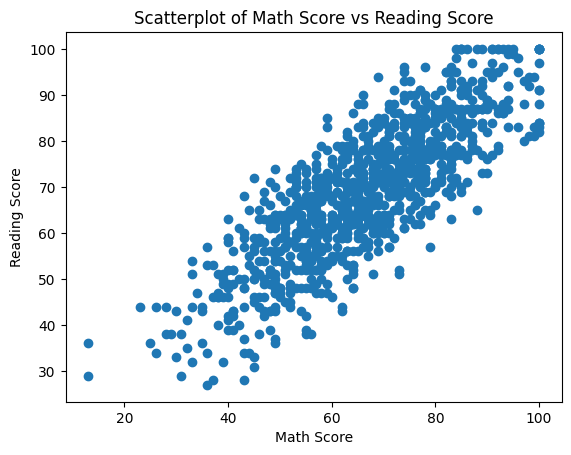

In [30]:
plt.scatter(df["math score"], df['reading score'])
plt.title("Scatterplot of Math Score vs Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

The relationship between Math Scores and Reading Scores seems positive. There are two visual low leverage points, sitting at below 20 on the x-axis (revisit the analysis on math scores).

<hr>

Generate box-plot between Test Preparation Course Completion and Math Scores

/var/folders/ly/13zzqyf97z934rzn1kg26yd40000gn/T/ipykernel_57596/3547767340.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=test_cats)


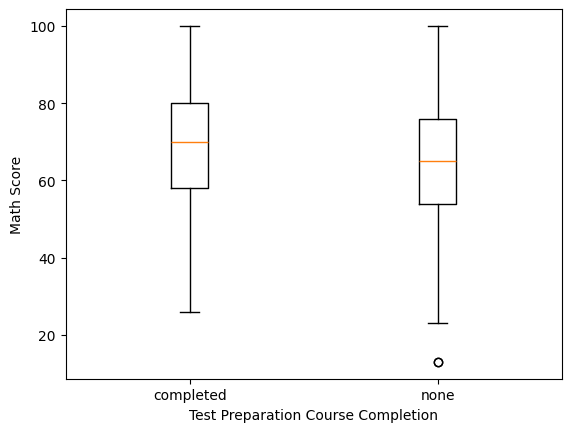

In [31]:
test_cats = df['test preparation course'].unique()
data = [df[df['test preparation course'] == cat]['math score'] for cat in test_cats]
plt.boxplot(data, labels=test_cats)
plt.xlabel("Test Preparation Course Completion")
plt.ylabel("Math Score")
plt.show()


In table form:

In [32]:
df.groupby("test preparation course").agg(
    mean_math = ("math score", "mean"),
    sd_math = ("math score", "std")
)

,mean_math,sd_math
test preparation course,,
completed,69.686567,15.216805
none,64.738346,15.239972


The students who took a test preparation course have a slightly higher mean math score. Both distributions have very similar standard deviations.

<hr>

### Conclusion
- In this analysis, we went into an exam dataset, detailing the math, reading, and writing scores of 1000 students. Below are the main observations/findings. 
- Observation 1: Each of the scores' distributions are symmetric and clustered around 60-70.
- Observation 2: Means in the dataset for test scores are similar.
- Observation 3: Race/ethnicity group E garnered the highest average test scores in this dataset.
- Observation 4: In the sample, Students who take a test prepration course got slightly higher math scores on.

Expansion Areas:
- Do more kinds of groupings and aggregations (grouping by different categories).
- Implement inferential tests for some analysis points. An example would be tests to determine if differences in test scores across categories are significantly different. Another one would be seeing if a test preparation course yields higher mean test scores via an indepdent samples test.
